
Notebook 4 — Customer Analytics

Objective
The purpose of this notebook is to analyze customer behavior, purchasing patterns, retention performance, and customer value using the Global Superstore dataset.

This notebook focuses on:
* customer intelligence
* retention analytics
* churn-risk analysis
* RFM analysis
* customer profitability
* behavioral trends

The resulting insights support:
* customer retention strategies
* executive decision-making
* segmentation models
* marketing optimization
* churn prediction systems


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
orders = pd.read_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/processed_orders.csv")
rfm = pd.read_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/rfm_dataset.csv")
orders["order_date"] = pd.to_datetime( orders["order_date"])
orders.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,...,loss_order_flag,total_orders,customer_lifetime_value,avg_order_value,product_total_sales,product_total_profit,regional_total_sales,high_sales_anomaly,extreme_discount_flag,negative_profit_flag
0,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,1,46,12589.95900,273.694761,15455.8125,-981.0675,1.100185e+06,1,0,1
1,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,0,58,19487.96376,335.999375,30041.5482,5455.9482,1.100185e+06,1,0,0
2,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,1,70,16394.46064,234.206581,11087.9550,-270.4350,2.822303e+06,1,0,1
3,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,0,7,3057.21000,436.744286,2832.9600,311.5200,7.837732e+05,1,0,0
4,22732,IN-2013-42360,2013-06-28,2013-07-01,Second Class,JM-15655,Jim Mitchum,Corporate,Sydney,New South Wales,...,0,68,16294.72706,239.628339,13715.3940,3638.2740,1.100185e+06,1,0,0


___________________________

Customer Overview 

1. Total Customers

In [3]:
total_customers = (orders["customer_id"] .nunique())
total_customers

1589

2. Total Orders

In [4]:
total_orders = (orders["order_id"].nunique())
total_orders

23805

3. Average Order Per Customer

In [5]:
avg_orders_per_customer = (total_orders / total_customers)
avg_orders_per_customer

14.981120201384519

Insights

Total Customers: A base of 1,589 total customers.

Total Orders: Substantial history of 23,805 unique orders.

Average Order Per Customer: A high customer lifetime value metric of 14.98 orders per customer .

Taken together, these data points reveal a highly stable and loyal consumer base, demonstrating that the business relies on repeat purchasing behavior from its core audience to drive sustained transactional growth rather than depending on single, one-off purchases.

Customer Lifetime Value Analysis

1. CLV Table

In [6]:
customer_clv = ( orders.groupby("customer_id").agg({"sales": "sum","profit": "sum", "order_id": "count"}) .reset_index())
customer_clv.columns = [ "customer_id", "customer_lifetime_value", "total_profit", "total_orders"]
customer_clv.head()

,customer_id,customer_lifetime_value,total_profit,total_orders
0,AA-10315,13747.41300,447.69050,42
1,AA-10375,5426.47900,860.38140,39
2,AA-10480,17342.02978,1395.49958,35
3,AA-10645,14987.77060,2978.84890,67
4,AA-315,2243.25600,535.56600,8


2. Top Customers by CLV

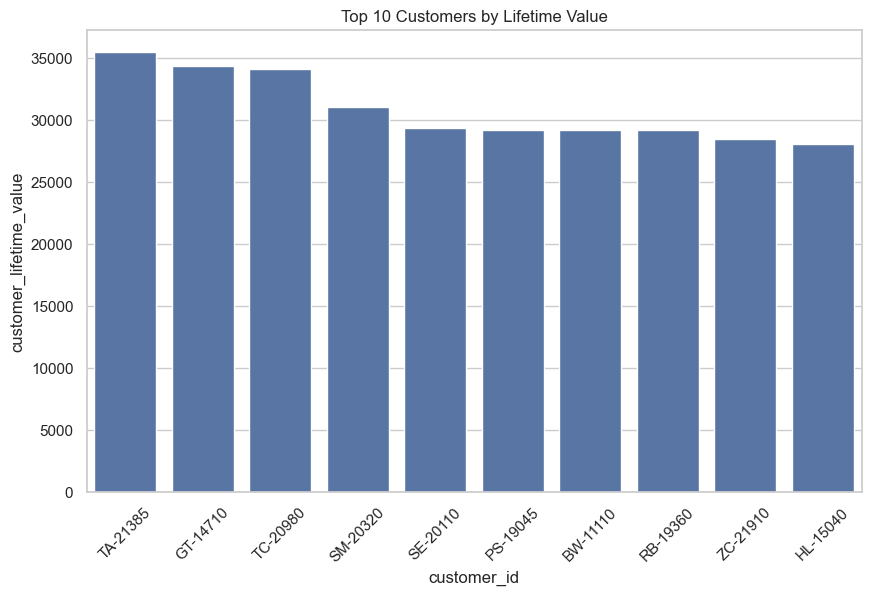

In [8]:
top_customers = (customer_clv.sort_values(by="customer_lifetime_value",ascending=False).head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=top_customers,x="customer_id",y="customer_lifetime_value")
plt.title("Top 10 Customers by Lifetime Value")
plt.xticks(rotation=45)
plt.show()

-------------------------

Purchase Frequency Analysis

1. Purchase Frequency

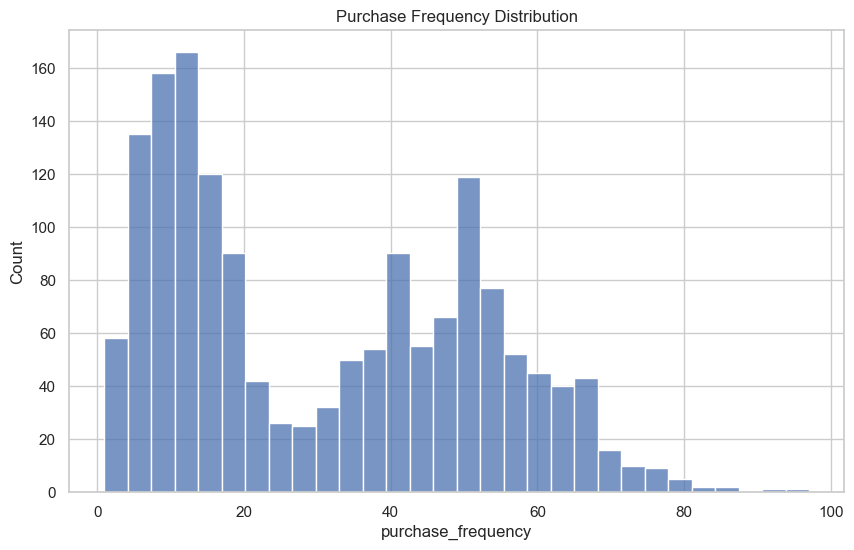

In [9]:
purchase_frequency = ( orders.groupby("customer_id") ["order_id"].count().reset_index())
purchase_frequency.columns = ["customer_id","purchase_frequency"]

plt.figure(figsize=(10,6))
sns.histplot(purchase_frequency["purchase_frequency"], bins=30)
plt.title("Purchase Frequency Distribution")
plt.show()


Insight 

The histogram plots the frequency count of customer transaction behaviors based on their individual purchase frequency rates. The visual landscape is distinctly multimodal, revealing two primary operational cohorts within the customer base.

The first and tallest cluster forms a sharp peak on the left side of the chart, maxing out between 5 and 15 purchases with counts climbing over 160. This indicates a massive segment of relatively low-frequency or newer buyers. Following a steep valley in the mid-20s, a broader secondary cluster emerges in the center of the chart, peaking locally around 50 purchases with a count near 120, before tapering off smoothly as it approaches a long tail on the far right near 100 purchases. This secondary distribution captures a highly active, high-value tier of loyal power buyers.

Ultimately, this split, non-normal distribution tells a vital story about customer engagement: instead of a uniform audience, the company is dealing with a bifurcated market made up of a high volume of casual buyers on one end, and a highly dedicated group of repeat purchasers on the other.

____________________________________________________________

Average Order Value Analysis

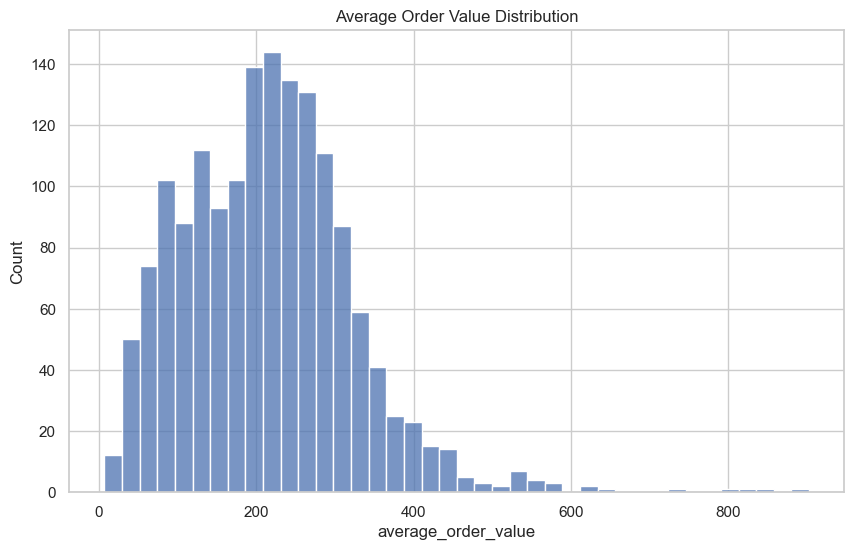

In [10]:
average_order_value = (orders.groupby("customer_id").agg({"sales": "mean"}).reset_index())
average_order_value.columns = ["customer_id","average_order_value"] 

plt.figure(figsize=(10,6))
sns.histplot(average_order_value["average_order_value"],bins=40)
plt.title("Average Order Value Distribution")
plt.show()


Insight

The graph illustrates the frequency count of customer spending behaviors based on their typical transactional values. In contrast to the split, multimodal pattern seen in purchase frequency, this distribution is a classic right-skewed (positively skewed) unimodal curve.

The vast majority of the company's clientele fall into a predictable sweet spot, with the chart peaking sharply between 200 and 250 in average order value, where frequency counts consistently exceed 140. From this core concentration, the data tapers off gradually to the left toward a floor of zero, while exhibiting a long, thin tail stretching far to the right past 600 and peaking occasionally near 900. This structural shape provides an important consumer insight: while the day-to-day operations of the business are supported by a highly reliable middle-class transaction standard, it occasionally captures rare, high-value bulk buyers who skew the absolute upper boundaries of order value distribution.

_____________________________

RFM Analysis

In [11]:
rfm.head()

,customer_id,recency,frequency,monetary,days_since_purchase,churn_risk
0,AA-10315,8,42,13747.41300,8,0
1,AA-10375,6,42,5884.19500,6,0
2,AA-10480,125,38,17695.58978,125,1
3,AA-10645,28,73,15343.89070,28,0
4,AA-315,2,8,2243.25600,2,0


1. Correlation Matrix

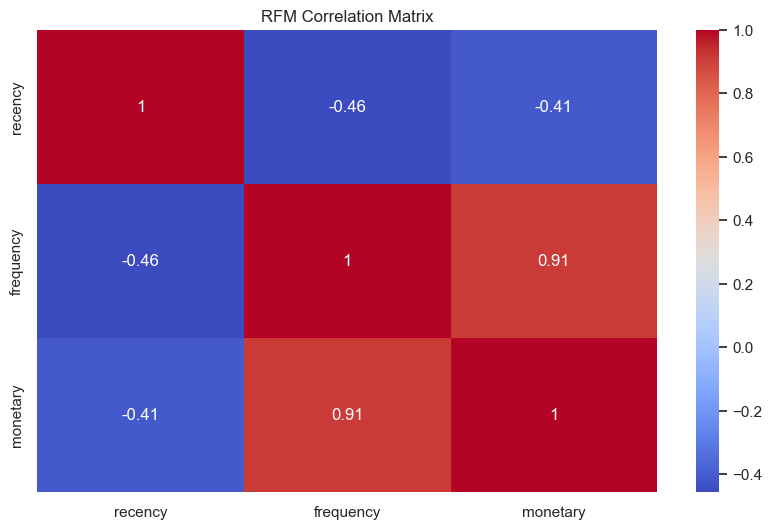

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(rfm[["recency", "frequency", "monetary"]].corr(),annot=True,cmap="coolwarm")
plt.title("RFM Correlation Matrix")
plt.show()

Insights

The graph utilizes a color-coded heatmap to evaluate the linear relationships between the three core pillars of customer value modeling: recency, frequency, and monetary value. The chart features a distinct diagonal of dark red squares showing a perfect correlation of 1.0 where each variable intersects with itself, while the remaining sectors use a diverging cool-to-warm color scale to highlight positive and negative behavioral links.

The standout revelation of the matrix is a near-perfect, explosive positive correlation (0.91) between frequency and monetary value. This exceptionally strong linear relationship indicates that a customer’s lifetime financial value is directly locked to their purchase volume—meaning that driving repeat transactions is the single most powerful mechanism for expanding individual account revenue.

Conversely, the matrix highlights notable negative correlations between recency and both frequency (-0.46) and monetary value (-0.41). In the context of RFM modeling, where "recency" typically measures the number of days since the last purchase, these negative coefficients reveal a positive behavioral trend: as the number of days since a customer last bought something decreases (meaning they bought something very recently), both their overall purchase frequency and total monetary contributions tend to increase. This statistical interaction confirms a highly active, compounding engagement cycle, proving that recently active buyers represent the highest-performing, highest-yielding segment of the company's customer base.

 2. Distributions

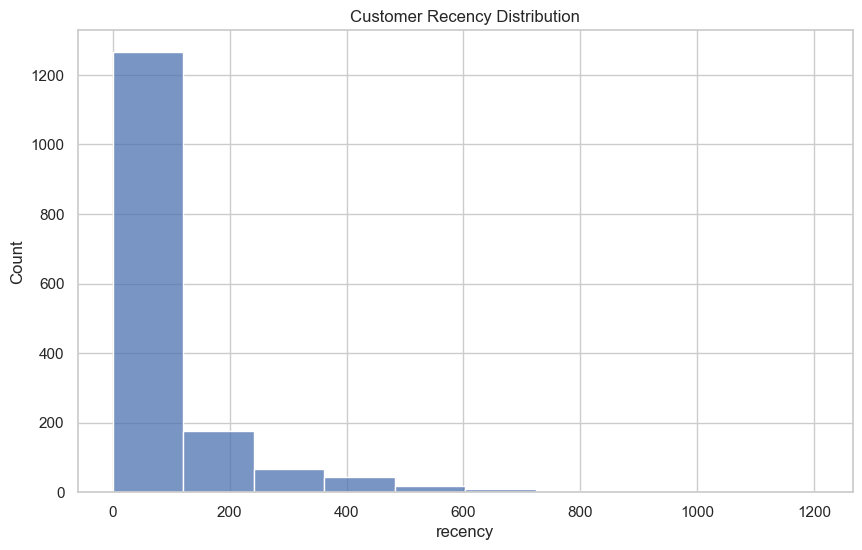

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(rfm["recency"],bins=10)
plt.title("Customer Recency Distribution")
plt.show()

Insights

The graph utilizes a vertical bar histogram to plot the frequency count of customers based on their recency metric (the number of days elapsed since their last purchase). The visual layout is heavily right-skewed (positively skewed), demonstrating a highly active and fresh consumer pipeline.

The chart features an overwhelming, dominant peak in the very first bin on the far left, where the frequency count for customers with a recency score between 0 and 100 days explodes past 1,200. From this massive initial concentration, the data drops precipitously, with the next cohort (100 to 200 days) falling below 200 counts. The distribution continues to flatten out drastically as it moves rightward, creating a long, thin tail that steps down through 400 and 600 days before entirely bottoming out out to 1,200 days.

This structural profile yields an important diagnostic for the business's health: the vast majority of the customer base has engaged with the company very recently, confirming excellent short-term retention and a low immediate churn rate, while dormant or lost accounts represent only a minor fraction of the total population.

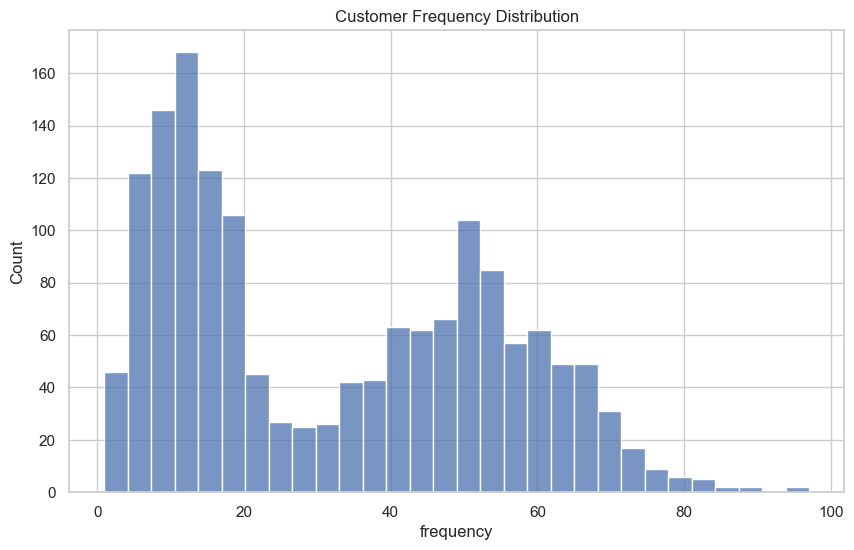

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(rfm["frequency"],bins=30)
plt.title("Customer Frequency Distribution")
plt.show()

Insight 

The final graph uses a vertical bar histogram to break down the frequency count of customers based on their total transaction volume.

The chart exhibits a distinct multimodal (bimodal) distribution, effectively segmenting the company's clientele into two primary behavioral archetypes. The first, most dominant spike occurs early on the left, peaking sharply between 10 and 15 transactions with a count exceeding 160 customers. This represents a heavy concentration of standard, occasional buyers or relatively new accounts. Moving rightward, the distribution drops into a shallow valley throughout the 20-to-30 transaction range before climbing back up into a second, broader wave. This mid-tier cluster forms a local peak around 50 transactions with a count of over 100, capturing a highly engaged, loyal consumer segment before trailing off smoothly into a long tail that bottoms out near 100 transactions.

This clear division confirms that the business is supported by two separate customer dynamics rather than a uniform audience: a high-volume base of casual buyers who provide consistent baseline transactions, and a secondary, robust group of highly dedicated repeat shoppers who drive sustained long-term engagement.

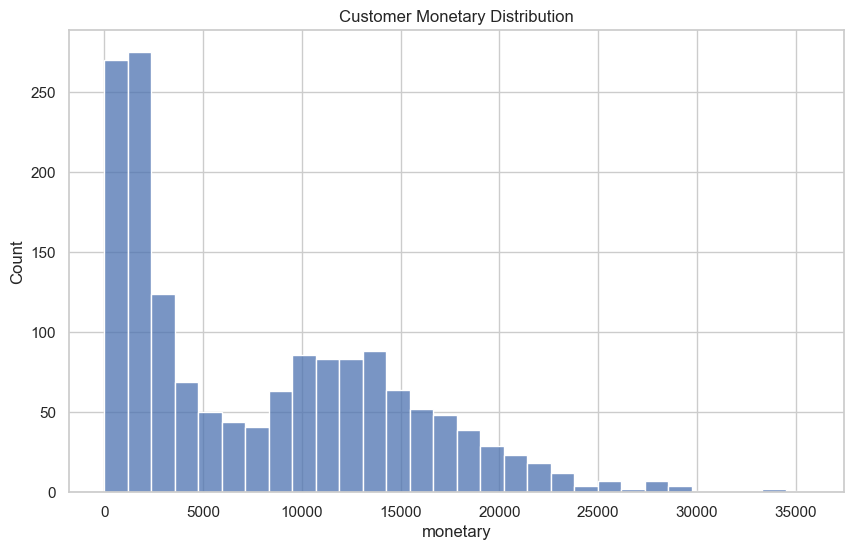

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(rfm["monetary"],bins=30)
plt.title("Customer Monetary Distribution")
plt.show()

Insights 

The graph uses a vertical bar histogram to plot the frequency count of customers based on their total financial value (monetary contribution) to the company.

Closely mirroring the bimodal architecture seen in the purchase frequency metrics, this distribution highlights a highly stratified consumer spending base. The chart features a massive, sharp spike on the far left, peaking aggressively between 1,000 and 2,000 with a count exceeding 270 customers. This initial concentration represents a large volume of low-to-mid tier spenders. Following a distinct downward slope into a valley around the 6,000-to-8,000 range, a second, broader wave of financial activity emerges in the center of the chart. This secondary cluster forms a local plateau between 10,000 and 14,000 with counts hovering near 80 to 90 customers, capturing a robust core of dedicated high-value accounts. Past 15,000, the data gradually declines into a long, trailing right tail that extends toward 30,000 and beyond.

This structural composition offers clear strategic insight for customer equity management: the business relies on a dual-engine revenue system. It is heavily anchored by an expansive base of lower-value transactional buyers, but gains significant financial stability from a highly distinct, secondary cluster of big-ticket repeat spenders.

---------------------------

Customer Segmentation Insights

In [19]:
rfm["customer_segment"] = np.where(rfm["monetary"] >= rfm["monetary"].quantile(0.75),"High Value","Standard")
rfm["customer_segment"].value_counts()


customer_segment
Standard      1192
High Value     398
Name: count, dtype: int64

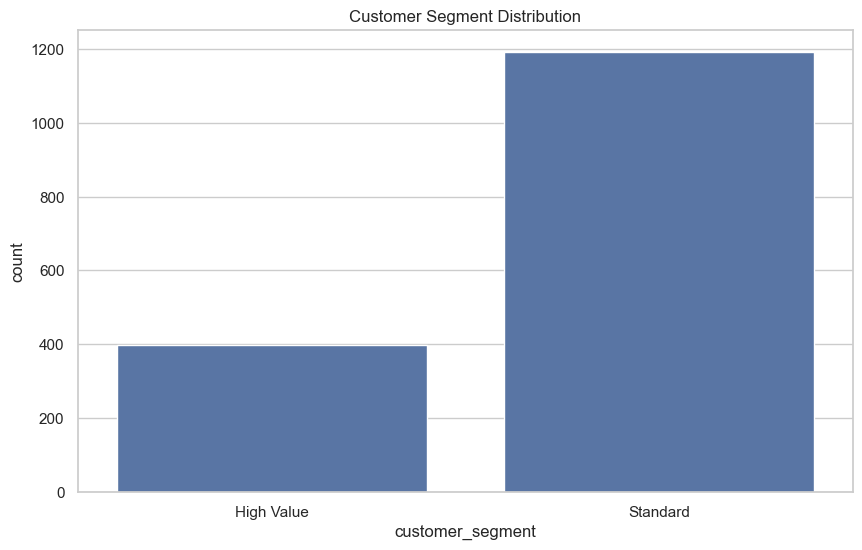

In [22]:
plt.figure(figsize=(10,6))
sns.countplot(data=rfm,x="customer_segment")
plt.title("Customer Segment Distribution")
plt.show()

Insights

The customer base is divided into two distinct groups based on lifetime financial contributions. By setting a threshold at the 75th percentile (quantile(0.75)) of the "monetary" column, the logic isolates the top 25% of spenders as "High Value" accounts, while designating the remaining 75% as "Standard" tier accounts. 

Standard Segment: Captures the broad majority of the audience with 1,192 customers.
High Value Segment: Pinpoints the elite spending cohort with 398 customers.

This straightforward, rule-based classification provides immediate strategic value for targeted marketing, loyalty programs, and resource allocation, allowing the company to separate its high-volume baseline audience from the vital, high-yield accounts that drive disproportional financial returns.

----------------------------

Churn Analytics Risk

In [23]:
rfm["churn_risk"].value_counts()

churn_risk
0    1152
1     438
Name: count, dtype: int64

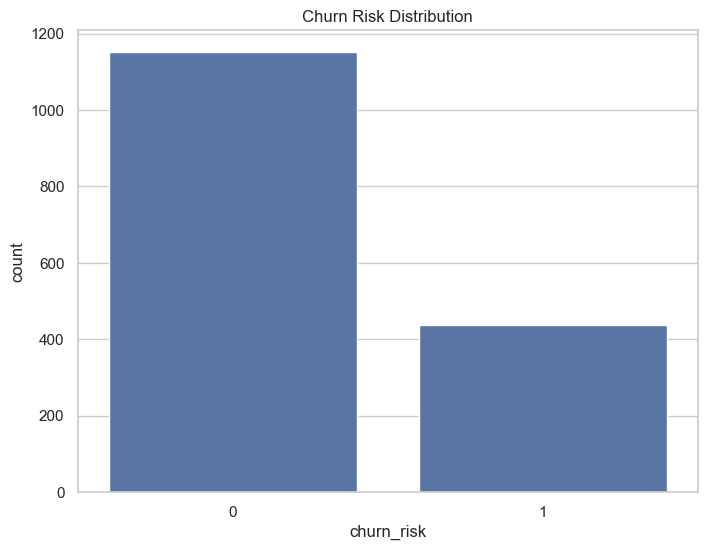

In [24]:
plt.figure(figsize=(8,6))
sns.countplot(data=rfm,x="churn_risk")
plt.title("Churn Risk Distribution")
plt.show()

Insight: 

Churn definition: Customers who havent made a purchase in 90 days.

The visualization presents a clear, binary operational breakdown where customers are categorized into two structural buckets: 0 (representing low churn risk or active loyal customers) and 1 (representing high churn risk or at-risk accounts). The distribution is highly uneven, with the low-risk segment (0) acting as the dominant group, towering over the chart with a count of approximately 1,150 customers. In contrast, the high-risk cohort (1) represents a much smaller fraction of the population, tracking at roughly 440 customers.

This structural composition offers a reassuring diagnostic for the business's immediate stability: the vast majority of the company's clientele remains firmly anchored in the safe, active category, meaning that while there is a notable portion of the audience showing early signs of attrition that requires targeted re-engagement, the healthy core of the consumer pipeline is firmly intact.

2. High-risk Customers

In [25]:
high_risk_customers = rfm[rfm["churn_risk"] == 1]
high_risk_customers.head()

,customer_id,recency,frequency,monetary,days_since_purchase,churn_risk,customer_segment
2,AA-10480,125,38,17695.58978,125,1,High Value
5,AA-375,253,13,654.49200,253,1,Standard
6,AA-480,314,10,2063.49300,314,1,Standard
16,AB-15,412,12,4607.13000,412,1,Standard
17,AB-150,398,8,3143.88000,398,1,Standard


3. Revenue At Risk

In [26]:
revenue_at_risk = (high_risk_customers["monetary"].sum())
print("The monetary value at risk: " ,revenue_at_risk)

The monetary value at risk:  1159869.70898


Insight

Revenue At Risk: The evaluation yields an alarming printed diagnostic: 1,159,869.71 in total historical revenue is currently tied to these unstable accounts.

Considered as a whole, this diagnostic visualization shifts the focus from simple counts to actual financial exposure. It serves as a stark warning for management that attrition is not merely a low-tier retention issue; it is actively threatening over a million units in total customer equity, underscoring the urgent need for a high-priority proactive win-back campaign targeting endangered power spenders.

__________________________________

Cohort Retention Analysis

In [27]:
from operator import attrgetter
orders["order_month"] = (orders["order_date"].dt.to_period("M"))
orders["cohort_month"] = (orders.groupby("customer_id")["order_date"].transform("min").dt.to_period("M"))
orders["cohort_index"] = ((orders["order_month"]- orders["cohort_month"]).apply(attrgetter("n")))

cohort_data = ( orders.groupby(["cohort_month","cohort_index"])["customer_id"].nunique().reset_index())
cohort_table = cohort_data.pivot(index="cohort_month",columns="cohort_index",values="customer_id")

cohort_size = cohort_table.iloc[:,0]
retention_matrix = cohort_table.divide(cohort_size,axis=0)

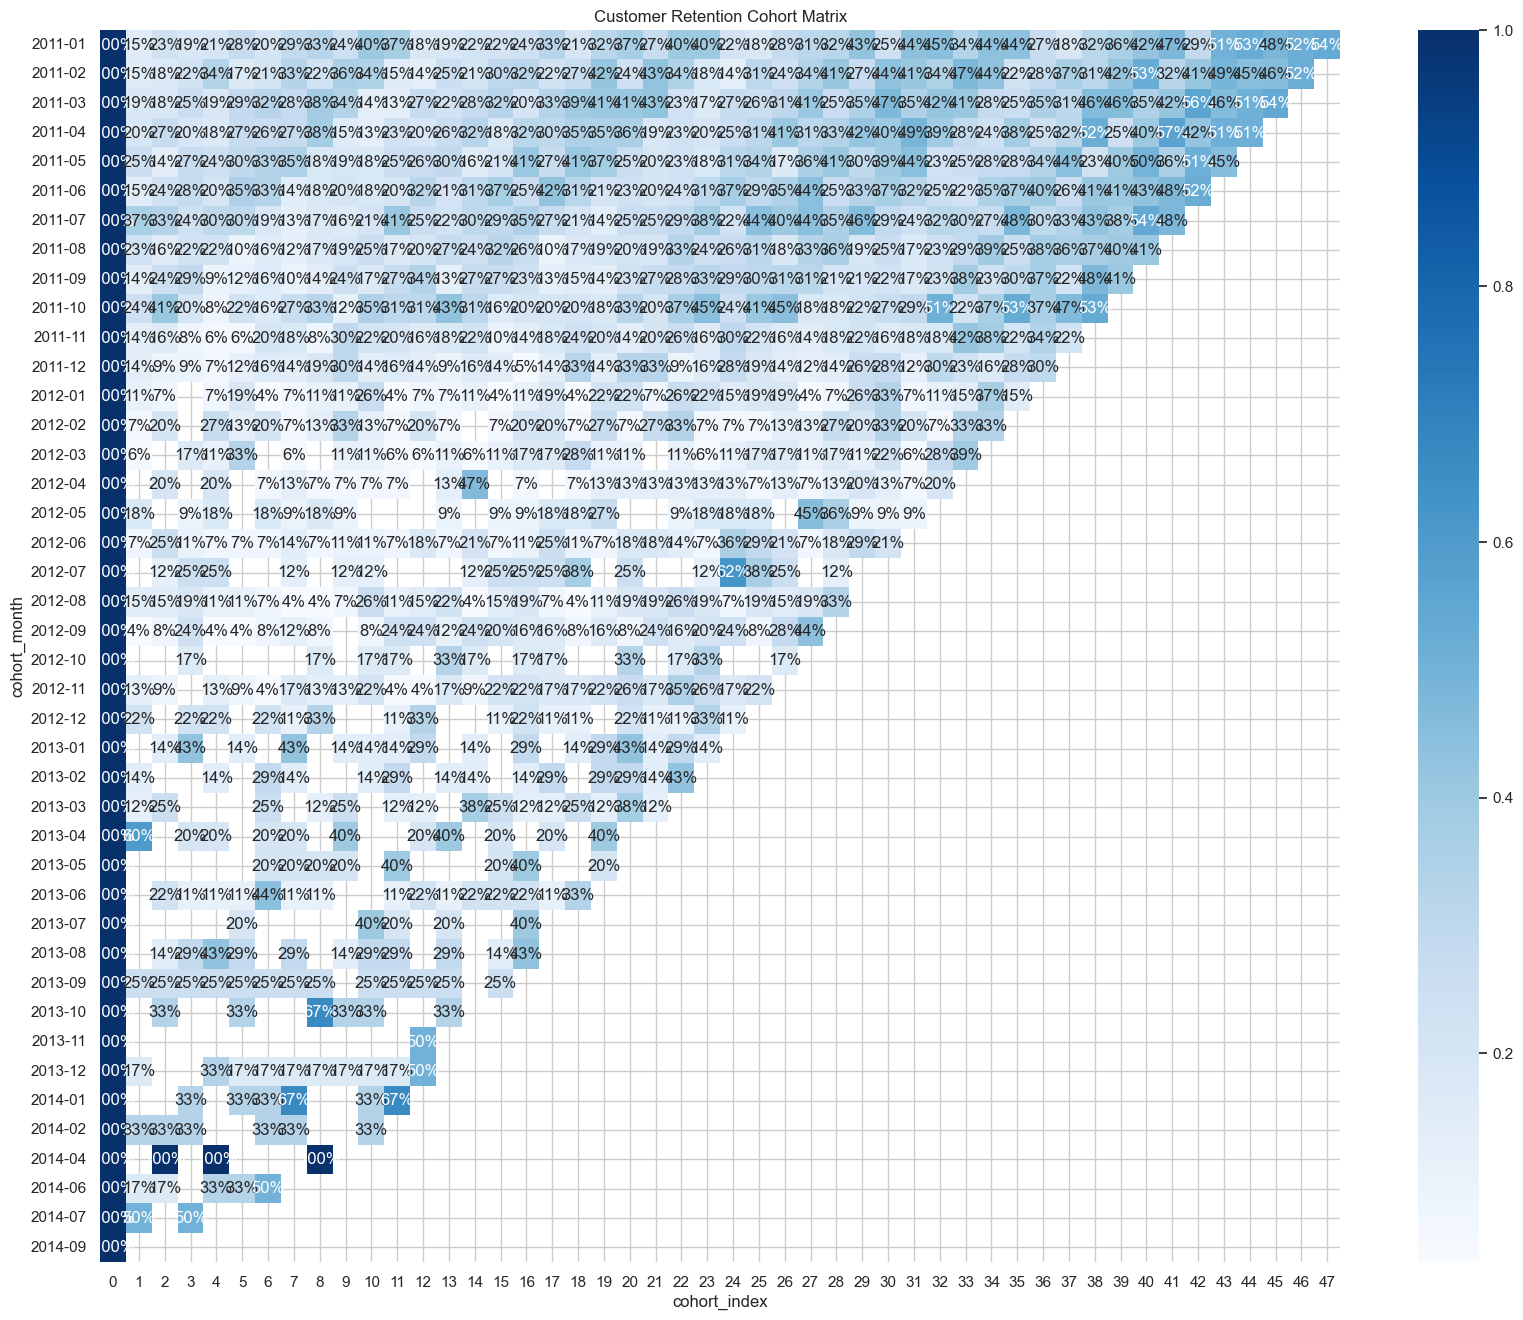

In [28]:
plt.figure(figsize=(20,16))
sns.heatmap(retention_matrix,annot=True,fmt=".0%",cmap="Blues")
plt.title("Customer Retention Cohort Matrix")
plt.show()

---------------

Customer Geographic Analysis

1. Customers By Region

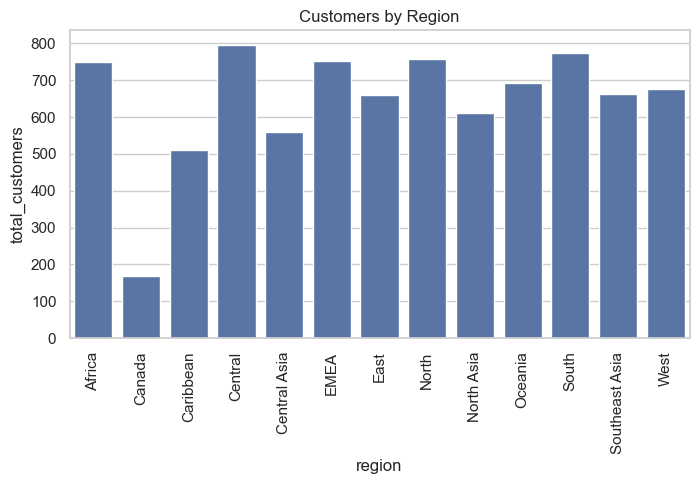

In [30]:
regional_customers = (orders.groupby("region")["customer_id"].nunique().reset_index())
regional_customers.columns = ["region","total_customers"]

plt.figure(figsize=(8,4))
sns.barplot(data=regional_customers,x="region",y="total_customers")
plt.title("Customers by Region")
plt.xticks(rotation=90)
plt.show()

Insights

The graph utilizes a discrete vertical bar chart to compare the total volume of unique customers distributed across thirteen distinct global market territories.

The chart reveals a highly diversified and globally balanced consumer footprint, with the vast majority of international regions demonstrating a consistently high, uniform scale of engagement. Specifically, major hubs such as Central, South, North, Africa, and EMEA stand out as primary strongholds, each anchoring a massive customer volume that hovers near the upper boundary of 750 to 800 unique clients. Smaller regional corridors, including Oceania, West, East, and Southeast Asia, also show substantial market penetration, clustering tightly in a highly healthy 650 to 700 customer range.

Conversely, the distribution highlights a clear geographic anomaly on the lower end: while the Caribbean and Central Asia show moderate footprints at around 500 to 550 customers, Canada trails as a drastic outlier on the far left, plunging below a count of 200.

Considered as a whole, this regional analysis provides crucial strategic insight for localized growth operations. It confirms that the company has successfully scaled its presence into a highly uniform, multi-continental player, while explicitly isolating Canada as a deeply underpenetrated territory that requires targeted customer acquisition campaigns and localized logistics expansion.

______________________________

Customer Profitablity Analysis

In [31]:
customer_profitability = (orders.groupby("customer_id")["profit"].sum() .reset_index())
customer_profitability.columns = ["customer_id","total_profit"]

1. Top Profitable Customers

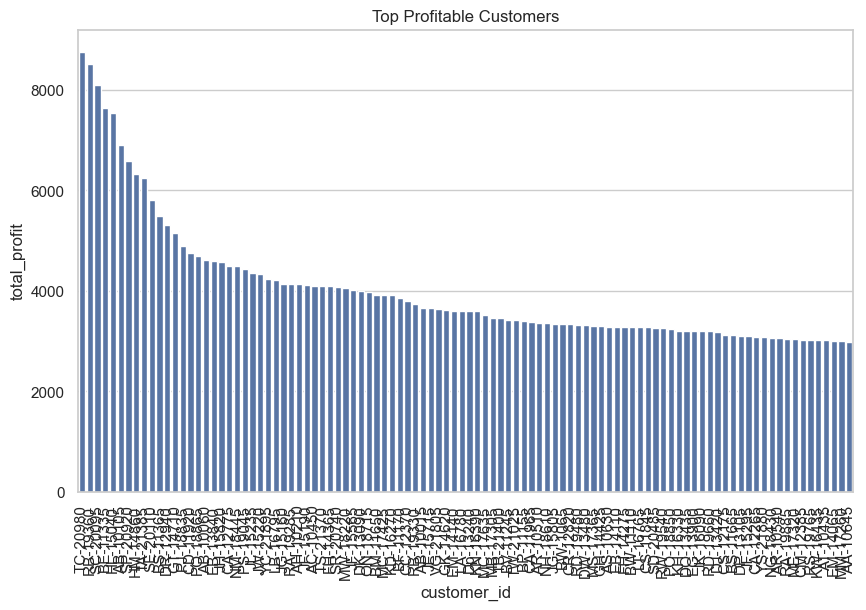

In [37]:
top_profitable_customers = (customer_profitability.sort_values(by="total_profit",ascending=False ).head(100))

plt.figure(figsize=(10,6))
sns.barplot(data=top_profitable_customers,x="customer_id",y="total_profit")
plt.title("Top Profitable Customers")
plt.xticks(rotation=90)
plt.show()

Insight

The chart illustrates a classic Pareto-style power-law distribution, highlighting a small, elite group of hyper-profitable clients who contribute disproportionately to the company's bottom line. At the absolute apex on the far left, the top three flagship customers act as massive revenue engines, with individual total profit contributions soaring past 8,000 to nearly 9,000. Following this initial spike, the chart exhibits a steep, rapid descent over the first ten to fifteen bars, with profit levels dropping into the 5,000 range. Past this initial drop-off, the distribution transitions into a long, highly stable plateau, gradually smoothing out and consolidating between 4,000 and 3,600 for the remaining majority of the featured power buyers

_____________________________

Customer Behaviour Trends

1. Monthly Customer Activity 

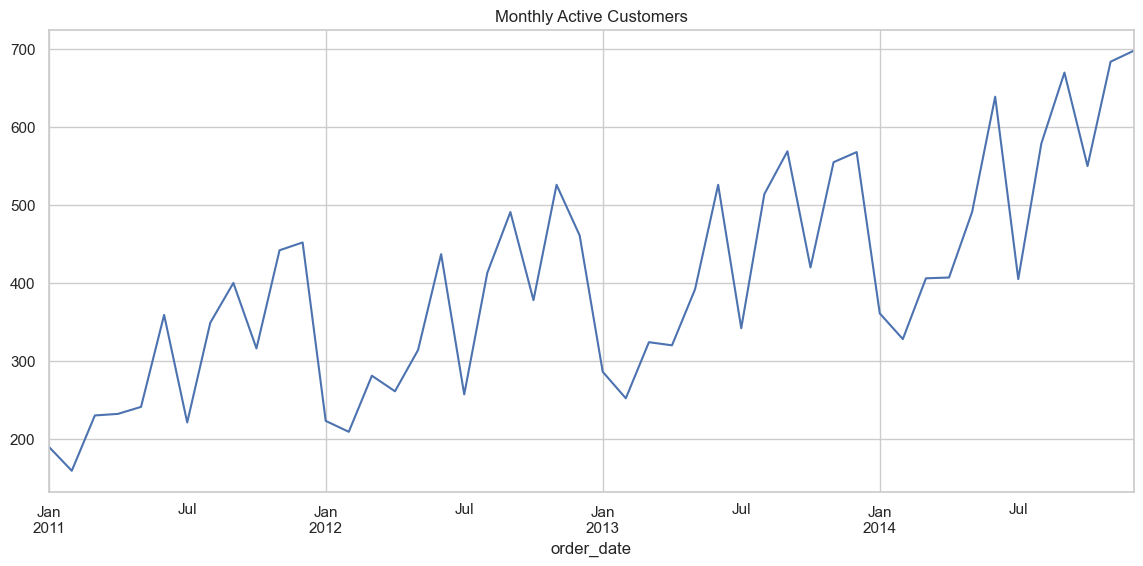

In [38]:
monthly_customers = (orders.groupby(orders["order_date"].dt.to_period("M"))["customer_id"].nunique())

plt.figure(figsize=(14,6))
monthly_customers.plot()
plt.title("Monthly Active Customers")
plt.show()

Insights

The chart reveals a powerful, highly encouraging macro-economic trend for the business: a sustained, long-term secular upward trajectory. Starting at its absolute historical baseline in early 2011 with fewer than 200 active customers, the monthly engagement scale undergoes exponential growth over the four-year window, ultimately skyrocketing to a record high approaching 700 active customers by late 2014.

However, beneath this strong growth trend lies a pattern of intense, recurring seasonal volatility. Each calendar year follows a matching behavioral loop: customer activity peaks sharply in the late summer and autumn months (consistently driving major spikes around July and November), which is immediately followed by a steep, predictable cliff-dive in January. This recurring sawtooth drop-off is most visible in January 2012 and January 2013, where active customer counts drop back toward the 200 and 250 baselines, respectively.

Considered alongside the previous revenue and retention analytics, this line chart provides vital context for the company's expansion. It proves that the business is successfully compounding its overall market reach and scaling its customer acquisition year-over-year. To stabilize this growth and prevent severe off-season drops, management must introduce targeted marketing promotions or inventory shifts specifically designed to boost engagement during the traditional post-holiday winter slump.

____________________

Customer Dashboard Tables

1. Customer Summary Table 

In [39]:
customer_summary = (orders.groupby("customer_id").agg({"sales": "sum", "profit": "sum","order_id": "count"}).reset_index())
customer_summary.columns = ["customer_id","total_sales","total_profit","total_orders"]


In [40]:
customer_summary.to_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/customer_summary.csv",index=False)
retention_matrix.to_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/retention_matrix.csv")

Conclusion
This notebook developed a comprehensive customer analytics framework using the Global Superstore dataset.

Key accomplishments include:
* customer lifetime value analysis
* churn-risk analytics
* RFM analysis
* cohort retention analysis
* customer profitability analysis
* customer segmentation foundations
* customer intelligence reporting

The analytical outputs generated in this notebook establish the foundation for:
* advanced customer segmentation
* churn prediction systems
* retention strategies
* Power BI dashboards
* executive customer reporting

This notebook demonstrates enterprise-level customer analytics and behavioral intelligence capabilities commonly used in modern analytics environments.
